# Premix

## Определение:
- витаминные
- 
- 
- 

In [58]:
import datetime
import pingouin as pg
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'
sns.set_theme(context='talk', style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = 10, 7
plt.rcParams['font.size'] = 20
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['figure.titlesize'] = 32
plt.rcParams['axes.titlesize'] = 32
plt.rcParams['savefig.format'] = 'pdf'
plt.rcParams['figure.autolayout'] = 'true'
plt.rcParams['figure.frameon'] = 'false'
plt.rcParams['axes.spines.left'] = 'false'
plt.rcParams['axes.spines.right'] = 'false'
plt.rcParams['axes.spines.top'] = 'false'
plt.rcParams['legend.fancybox'] = 'false'
plt.rcParams['axes.spines.bottom'] = 'false'
plt.rcParams['font.size'] = 20
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
# для графиков, где надо много цветов, юзайте воть:
sns.set_palette(sns.color_palette('deep'))
# а по дефолту воть:
sns.set_palette(sns.color_palette('BuGn_r', n_colors=10)[2::3])
pd.set_option('display.max_columns', 60)

monthly_feeding = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Feeding')
herd_metrics = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Herd maintenance').replace('-', np.nan)
production_indicators = pd.read_excel('datasets/Ekoniva_dataset.xlsx', sheet_name='Dairy indicators').replace('-', np.nan)

herd_metrics["year_month"] = herd_metrics["date"].dt.to_period('M').astype(str)

fad = pd.read_csv("datasets//FeedingAndDetails_clear.csv", index_col=0)

fad["Date"] = pd.to_datetime(fad["Date"])
fad["year_month"] = fad["Date"].dt.to_period('M').astype(str)
fad = fad.rename(columns={"FarmName": "farm_name"})


In [59]:
production_indicators["year_month"] = production_indicators["date"].dt.to_period('M').astype(str)

In [60]:
df = fad.copy()
daily_group = df.groupby(['Date', 'farm_name', 'PhysiologicalGroupName', 'ingredient_name'], as_index=False).agg({
    'PhysicalWeight_kg': 'sum',
    'PhysiologicalGroupHeadCount': 'first'
})
daily_group

,Date,farm_name,PhysiologicalGroupName,ingredient_name,PhysicalWeight_kg,PhysiologicalGroupHeadCount
0,2022-01-01,ЖК Добрино,Д0 (Новотельные),вода,551.000,33
1,2022-01-01,ЖК Добрино,Д0 (Новотельные),глицерин,25.086,33
2,2022-01-01,ЖК Добрино,Д0 (Новотельные),жир защищённый,23.079,33
3,2022-01-01,ЖК Добрино,Д0 (Новотельные),жмых рапсовый,366.000,33
4,2022-01-01,ЖК Добрино,Д0 (Новотельные),комбикорм 10 группы,578.000,33
...,...,...,...,...,...,...
3623807,2025-10-22,РМ Торопово,Т4 (>1 года),клевер + тимофеевка сенаж,4549.000,93
3623808,2025-10-22,РМ Торопово,Т4 (>1 года),кукуруза силос,3520.000,93
3623809,2025-10-22,РМ Торопово,Т4 (>1 года),оболочка сои,422.000,93
3623810,2025-10-22,РМ Торопово,Т4 (>1 года),премикс молодняк 6-24,75.866,93


In [61]:
fad

,FeedingTaskID,Date,farm_name,FeedNumber,SectionID,PhysiologicalGroupID,PhysiologicalGroupName,PhysiologicalGroupHeadCount,Appetite,RationName,RationPart,TotalWeight_kg,CompletedAt,year,PhysicalWeight_kg,ingredient_name,ingredient_group,year_month
0,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,150.259,солома покупная,Объёмные корма,2022-01
1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,880.444,люцерна сенаж,Объёмные корма,2022-01
2,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,542.257,комбикорм 10 группы,Комбикорма и стартеры,2022-01
3,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,991.793,кукуруза сухая,Энергетические и крахмалистые корма,2022-01
4,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,156.054,шрот подсолнечный,Белковые корма,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16411360,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,120.643,солома (общ.),Объёмные корма,2025-10
16411361,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,549.169,люцерна сенаж,Объёмные корма,2025-10
16411362,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,36.676,жом свекловичный сухой,Жом и дробина,2025-10
16411363,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,10.049,премикс молодняк 6-24,"Премиксы, БАДы, дрожжи",2025-10


In [62]:
df = fad.copy()

grouped = df.groupby(
    ["Date", "farm_name", "PhysiologicalGroupName", "year_month"]
)["PhysicalWeight_kg"].sum().reset_index()

dff = df.groupby(["Date", "farm_name", "PhysiologicalGroupName", "SectionID"], as_index=False).agg(
    TrueHeadCount=("PhysiologicalGroupHeadCount", "max")
)

appetites = dff.groupby(
    ["Date", "farm_name", "PhysiologicalGroupName"]
).agg({
    "TrueHeadCount": "sum"
}).reset_index().rename(columns={"TrueHeadCount": "CowCount"})

appetites["CowCount"] = appetites["CowCount"]


date_phy_feeding = pd.merge(
    grouped,
    appetites,
    on=["Date", "farm_name", "PhysiologicalGroupName"],
    how="left"
)
date_phy_feeding["WeightPerCow"] = date_phy_feeding["PhysicalWeight_kg"] / date_phy_feeding["CowCount"]
date_phy_feeding

,Date,farm_name,PhysiologicalGroupName,year_month,PhysicalWeight_kg,CowCount,WeightPerCow
0,2022-01-01,ЖК Добрино,Д0 (Новотельные),2022-01,6076.165,136,44.677684
1,2022-01-01,ЖК Добрино,Д1,2022-01,143544.434,2710,52.968426
2,2022-01-01,ЖК Добрино,Д2,2022-01,16102.000,345,46.672464
3,2022-01-01,ЖК Добрино,Нетели,2022-01,29691.786,1245,23.848824
4,2022-01-01,ЖК Добрино,С1,2022-01,5237.236,172,30.449047
...,...,...,...,...,...,...,...
520366,2025-10-22,РМ Поляна,Т2 (6-8 мес.),2025-10,2773.000,175,15.845714
520367,2025-10-22,РМ Поляна,Т3 (9-12 мес.),2025-10,3196.000,158,20.227848
520368,2025-10-22,РМ Торопово,Нетели,2025-10,26393.897,988,26.714471
520369,2025-10-22,РМ Торопово,Т3 (9-12 мес.),2025-10,2932.291,150,19.548607


In [63]:
fad

,FeedingTaskID,Date,farm_name,FeedNumber,SectionID,PhysiologicalGroupID,PhysiologicalGroupName,PhysiologicalGroupHeadCount,Appetite,RationName,RationPart,TotalWeight_kg,CompletedAt,year,PhysicalWeight_kg,ingredient_name,ingredient_group,year_month
0,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,150.259,солома покупная,Объёмные корма,2022-01
1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,880.444,люцерна сенаж,Объёмные корма,2022-01
2,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,542.257,комбикорм 10 группы,Комбикорма и стартеры,2022-01
3,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,991.793,кукуруза сухая,Энергетические и крахмалистые корма,2022-01
4,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,156.054,шрот подсолнечный,Белковые корма,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16411360,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,120.643,солома (общ.),Объёмные корма,2025-10
16411361,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,549.169,люцерна сенаж,Объёмные корма,2025-10
16411362,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,36.676,жом свекловичный сухой,Жом и дробина,2025-10
16411363,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,10.049,премикс молодняк 6-24,"Премиксы, БАДы, дрожжи",2025-10


In [64]:
fad.columns

Index(['FeedingTaskID', 'Date', 'farm_name', 'FeedNumber', 'SectionID',
       'PhysiologicalGroupID', 'PhysiologicalGroupName',
       'PhysiologicalGroupHeadCount', 'Appetite', 'RationName', 'RationPart',
       'TotalWeight_kg', 'CompletedAt', 'year', 'PhysicalWeight_kg',
       'ingredient_name', 'ingredient_group', 'year_month'],
      dtype='object')

In [65]:
fad['ingredient_group'].unique()

array(['Объёмные корма', 'Комбикорма и стартеры',
       'Энергетические и крахмалистые корма', 'Белковые корма',
       'Жиры и глюкозогенные добавки', 'Жидкости',
       'Премиксы, БАДы, дрожжи', 'Минералы/буферные', 'Жом и дробина',
       'Остатки'], dtype=object)

In [66]:
cols = [
    'Date', 'farm_name', 'SectionID', 'PhysiologicalGroupName', 'FeedingTaskID',
    'ingredient_group'
]

df = fad[cols].copy()
df['has_premix'] = (df['ingredient_group'] == 'Премиксы, БАДы, дрожжи').astype(int)
df['has_combifeed'] = (df['ingredient_group'] == 'Комбикорма и стартеры').astype(int)


group_cols = [
    'Date',
    'farm_name',
    'SectionID',
    'PhysiologicalGroupName',
    'FeedingTaskID'
]

task_flags = (
    df.groupby(group_cols, as_index=False)
      .agg({
          'has_premix': 'max',
          'has_combifeed': 'max'
      })
)



def classify(row):
    p, c = row['has_premix'], row['has_combifeed']

    if p == 1 and c == 1:
        return 'premix_and_combifeed'
    elif p == 1 and c == 0:
        return 'premix_only'
    elif p == 0 and c == 1:
        return 'combifeed_only'
    else:
        return 'no_premix_no_combifeed'

task_flags['ration_type'] = task_flags.apply(classify, axis=1)


task_flags

,Date,farm_name,SectionID,PhysiologicalGroupName,FeedingTaskID,has_premix,has_combifeed,ration_type
0,2022-01-01,ЖК Добрино,1,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
1,2022-01-01,ЖК Добрино,1,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
2,2022-01-01,ЖК Добрино,2,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
3,2022-01-01,ЖК Добрино,2,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
4,2022-01-01,ЖК Добрино,3,Д1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,0,1,combifeed_only
...,...,...,...,...,...,...,...,...
2154459,2025-10-22,РМ Торопово,9,Нетели,Farms/EkoNiva1C.4f7ebea9-ae74-11e7-80bc-1c98ec...,1,0,premix_only
2154460,2025-10-22,РМ Торопово,9,Нетели,Farms/EkoNiva1C.4f7ebea9-ae74-11e7-80bc-1c98ec...,1,0,premix_only
2154461,2025-10-22,РМ Торопово,9,Нетели,Farms/EkoNiva1C.4f7ebea9-ae74-11e7-80bc-1c98ec...,1,0,premix_only
2154462,2025-10-22,РМ Торопово,9,Нетели,Farms/EkoNiva1C.4f7ebea9-ae74-11e7-80bc-1c98ec...,1,0,premix_only


In [67]:
task_flags['ration_type'].unique()

array(['combifeed_only', 'premix_and_combifeed', 'premix_only',
       'no_premix_no_combifeed'], dtype=object)

In [68]:
fad['FeedingTaskID'].nunique()

1076769

In [69]:
task_flags['PhysiologicalGroupName'].unique()

array(['Д1', 'Д0 (Новотельные)', 'Т1 (3-5 мес.)', 'Т4 (>1 года)',
       'Нетели', 'С1', 'С2', 'Т3 (9-12 мес.)', 'Д2', 'Т2 (6-8 мес.)',
       'Т0 (0-2 мес.)', 'Н Нетели', 'Д3 (Предзапуск)', 'Б0 (0-2 мес.)',
       'Т3 9-12', 'Т0', 'D3', 'Д3', 'Нетели 1  группа', 'Б3 (9-12 мес.)',
       'Т0 (3-5 мес.)', 'Д0', 'Сух-2', 'Д-3', 'Т2', 'МГ Т3', 'Т2 6-8',
       'сух 2', 'сух 1', 'С2 нетели', 'С1 нетели', 'Т4', 'Н НЕТЕЛИ', 'Т3',
       'Б2 (6-8 мес.)', 'Б1 (3-5 мес.)', 'Т4 13-20', 'Телята СВОД Навесы',
       'Сух 2 Нетели', 'МГ Т2', 'Т3 (9-12 мес)', 'МП Коровы', 'МП Нетели',
       'МП БП (бык-производитель)', 'Б4 (>1 года)',
       'МП Б1 (6-12 мес. откорм)', 'МП БР2 (>1 года рем.)',
       'МП Т2 (>1 года откорм)', 'МП БР1 (6-12 мес. рем.)',
       'МП ТР1 (6-12 мес. рем.)', 'Телята домики', 'МП Т0 (0-6 мес.)',
       'МП ТР2 (>1 года рем.)', 'МП Б0 (0-6 мес.)',
       'МП Б2 (>1 года откорм)', 'С2 Нетели', 'быки племенные', 'Лошади',
       'Т0 (0-2 мес)', 'Коровы'], dtype=object)

In [70]:
def rename_shit(dff):
    """Renames bad PhysiologicalGroupNames"""
    mapping = {'Д0 (Новотельные)': 'Д0', 'Н Нетели': 'Нетели', 'Д3 (Предзапуск)': 'Д3', 'D3': 'Д3', 
               'Нетели 1  группа': 'Нетели','Сух-2': "С2", 'Д-3': 'Д3', 'сух 1': 'С1', 'сух 2': 'С2', 'С1 нетели': 'С1', 
               'С2 нетели': 'С2', 'Н НЕТЕЛИ': 'Нетели', 'Сух 2 Нетели': 'С2', 'С2 Нетели': 'С2'}

    dff["PhysiologicalGroupName"] = dff["PhysiologicalGroupName"].replace(mapping)
    return dff

task_flags = rename_shit(task_flags)
fad = rename_shit(fad)

In [71]:
doynye = ["Д0", "Д1", "Д2", "Д3"]
suhostoy = ['С1', 'С2']

In [72]:
fad = fad.merge(
    task_flags[group_cols + ['ration_type']],
    on=group_cols,
    how='left'
)

In [73]:
production_indicators

,date,region,prod_farm_name,farm_type,farm_name,cows_total,milk_cows,milk_cows_d0,milk_cows_d1,milk_cows_d2,milk_cows_d3,weekly_milking_per_cow,gross_milk_yield,cow_retired,cow_retired_low_prod,cow_retired_hooves,cow_retired_inj_joint,cow_retired_mastit,cow_retired_jkt,bull_num,year_month
0,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12
1,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров-2,2882.0,2591.0,131.0,2149.0,261.0,50.0,36.3,88816.0,68.0,NaN,NaN,NaN,NaN,NaN,18.0,2022-12
2,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Верхний Икорец,2893.0,2580.0,101.0,2104.0,375.0,0.0,38.3,98563.0,85.0,NaN,NaN,NaN,NaN,NaN,0.0,2022-12
3,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Петропавловка,2885.0,2686.0,90.0,2271.0,163.0,162.0,35.2,87647.0,153.0,NaN,NaN,NaN,NaN,NaN,26.0,2022-12
4,2022-12-01,Воронеж,ЭНА Восток,МТФ,МТФ ЭНАВ,799.0,738.0,8.0,507.0,0.0,223.0,NaN,NaN,66.0,NaN,NaN,NaN,NaN,NaN,0.0,2022-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1742,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК,ЖК Елбань,5882.0,5468.0,169.0,4455.0,288.0,556.0,36.0,191276.0,526.0,0.0,14.0,33.0,13.0,26.0,0.0,2025-07
1743,2025-07-01,Сибирь,Сибирская Нива Маслянино,ЖК,ЖК Пеньково,4666.0,4172.0,304.0,3023.0,559.0,286.0,36.7,147218.0,189.0,48.0,23.0,24.0,19.0,24.0,12.0,2025-07
1744,2025-07-01,Сибирь,Сибирская Нива Маслянино,РМ,РМ Пеньково,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,164.0,2025-07
1745,2025-07-01,Сибирь,Сибирская Нива Черепаново,ЖК,ЖК Огнева Заимка,3544.0,3140.0,214.0,1842.0,1027.0,57.0,40.4,119264.0,115.0,21.0,18.0,20.0,20.0,11.0,10.0,2025-07


In [74]:
fad

,FeedingTaskID,Date,farm_name,FeedNumber,SectionID,PhysiologicalGroupID,PhysiologicalGroupName,PhysiologicalGroupHeadCount,Appetite,RationName,RationPart,TotalWeight_kg,CompletedAt,year,PhysicalWeight_kg,ingredient_name,ingredient_group,year_month,ration_type
0,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,150.259,солома покупная,Объёмные корма,2022-01,combifeed_only
1,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,880.444,люцерна сенаж,Объёмные корма,2022-01,combifeed_only
2,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,542.257,комбикорм 10 группы,Комбикорма и стартеры,2022-01,combifeed_only
3,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,991.793,кукуруза сухая,Энергетические и крахмалистые корма,2022-01,combifeed_only
4,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2022-01-01,ЖК Добрино,15,9,2,Д1,352,0.9,Д1,0.5,8324.0,2022-01-03T05:45:50.5175580,2022,156.054,шрот подсолнечный,Белковые корма,2022-01,combifeed_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16411327,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,120.643,солома (общ.),Объёмные корма,2025-10,premix_only
16411328,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,549.169,люцерна сенаж,Объёмные корма,2025-10,premix_only
16411329,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,36.676,жом свекловичный сухой,Жом и дробина,2025-10,premix_only
16411330,Farms/EkoNiva1C.6c69fe1b-2b6f-11e8-80c4-1c98ec...,2025-10-22,ЖК Подболотье,20,131,1,Нетели,32,1.2,С1,1.0,1106.0,2025-10-22T08:50:05.2368034,2025,10.049,премикс молодняк 6-24,"Премиксы, БАДы, дрожжи",2025-10,premix_only


In [75]:
fad['year_month']

0           2022-01
1           2022-01
2           2022-01
3           2022-01
4           2022-01
             ...   
16411327    2025-10
16411328    2025-10
16411329    2025-10
16411330    2025-10
16411331    2025-10
Name: year_month, Length: 16411332, dtype: object

In [76]:
production_indicators['year_month']

0       2022-12
1       2022-12
2       2022-12
3       2022-12
4       2022-12
         ...   
1742    2025-07
1743    2025-07
1744    2025-07
1745    2025-07
1746    2025-07
Name: year_month, Length: 1747, dtype: object

In [77]:
fad_prod = production_indicators.merge(fad, on=['year_month', 'farm_name'], how='right')

In [78]:
dd = fad_prod[(fad_prod['PhysiologicalGroupName'].isin(doynye)) & (fad_prod['weekly_milking_per_cow'].notna())]
dd

,date,region,prod_farm_name,farm_type,farm_name,cows_total,milk_cows,milk_cows_d0,milk_cows_d1,milk_cows_d2,milk_cows_d3,weekly_milking_per_cow,gross_milk_yield,cow_retired,cow_retired_low_prod,cow_retired_hooves,cow_retired_inj_joint,cow_retired_mastit,cow_retired_jkt,bull_num,year_month,FeedingTaskID,Date,FeedNumber,SectionID,PhysiologicalGroupID,PhysiologicalGroupName,PhysiologicalGroupHeadCount,Appetite,RationName,RationPart,TotalWeight_kg,CompletedAt,year,PhysicalWeight_kg,ingredient_name,ingredient_group,ration_type
1950326,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,12.180,солома (общ.),Объёмные корма,combifeed_only
1950327,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,51.354,люцерна сенаж,Объёмные корма,combifeed_only
1950328,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,4.609,шрот рапсовый,Белковые корма,combifeed_only
1950329,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,13.826,шрот соевый,Белковые корма,combifeed_only
1950330,2022-12-01,Воронеж,ЭНА Восток,ЖК,ЖК Бобров,2878.0,2609.0,69.0,2094.0,340.0,106.0,34.1,86551.0,0.0,NaN,NaN,NaN,NaN,NaN,23.0,2022-12,Farms/EkoNiva1C.6dd689ea-831c-11e7-80bc-1c98ec...,2022-12-01,1,461,33,Д0,7,0.9,Д0,1.0,236.0,2022-12-01T03:46:00.0000000,2022,5.267,ячмень,Энергетические и крахмалистые корма,combifeed_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15170655,2025-07-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2988.0,2698.0,174.0,2369.0,0.0,155.0,42.4,112683.0,56.0,1.0,3.0,2.0,3.0,20.0,15.0,2025-07,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2025-07-31,33,74,2,Д1,352,1.0,Д1,1.0,17790.0,2025-08-01T06:21:04.2696412,2025,1128.000,комбикорм №10 эна лб,Комбикорма и стартеры,combifeed_only
15170656,2025-07-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2988.0,2698.0,174.0,2369.0,0.0,155.0,42.4,112683.0,56.0,1.0,3.0,2.0,3.0,20.0,15.0,2025-07,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2025-07-31,33,74,2,Д1,352,1.0,Д1,1.0,17790.0,2025-08-01T06:21:04.2696412,2025,504.000,жом свекловичный сухой,Жом и дробина,combifeed_only
15170657,2025-07-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2988.0,2698.0,174.0,2369.0,0.0,155.0,42.4,112683.0,56.0,1.0,3.0,2.0,3.0,20.0,15.0,2025-07,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2025-07-31,33,74,2,Д1,352,1.0,Д1,1.0,17790.0,2025-08-01T06:21:04.2696412,2025,5068.000,кукуруза силос,Объёмные корма,combifeed_only
15170658,2025-07-01,Воронеж,ЭНА Левый берег,ЖК,ЖК Добрино,2988.0,2698.0,174.0,2369.0,0.0,155.0,42.4,112683.0,56.0,1.0,3.0,2.0,3.0,20.0,15.0,2025-07,Farms/EkoNiva1C.216d4235-2852-11e8-80c4-1c98ec...,2025-07-31,33,74,2,Д1,352,1.0,Д1,1.0,17790.0,2025-08-01T06:21:04.2696412,2025,625.000,патока свекловичная,Энергетические и крахмалистые корма,combifeed_only


In [79]:
dd[dd['ration_type'] == 'combifeed_only']['weekly_milking_per_cow'].mean()

np.float64(37.121715192244295)

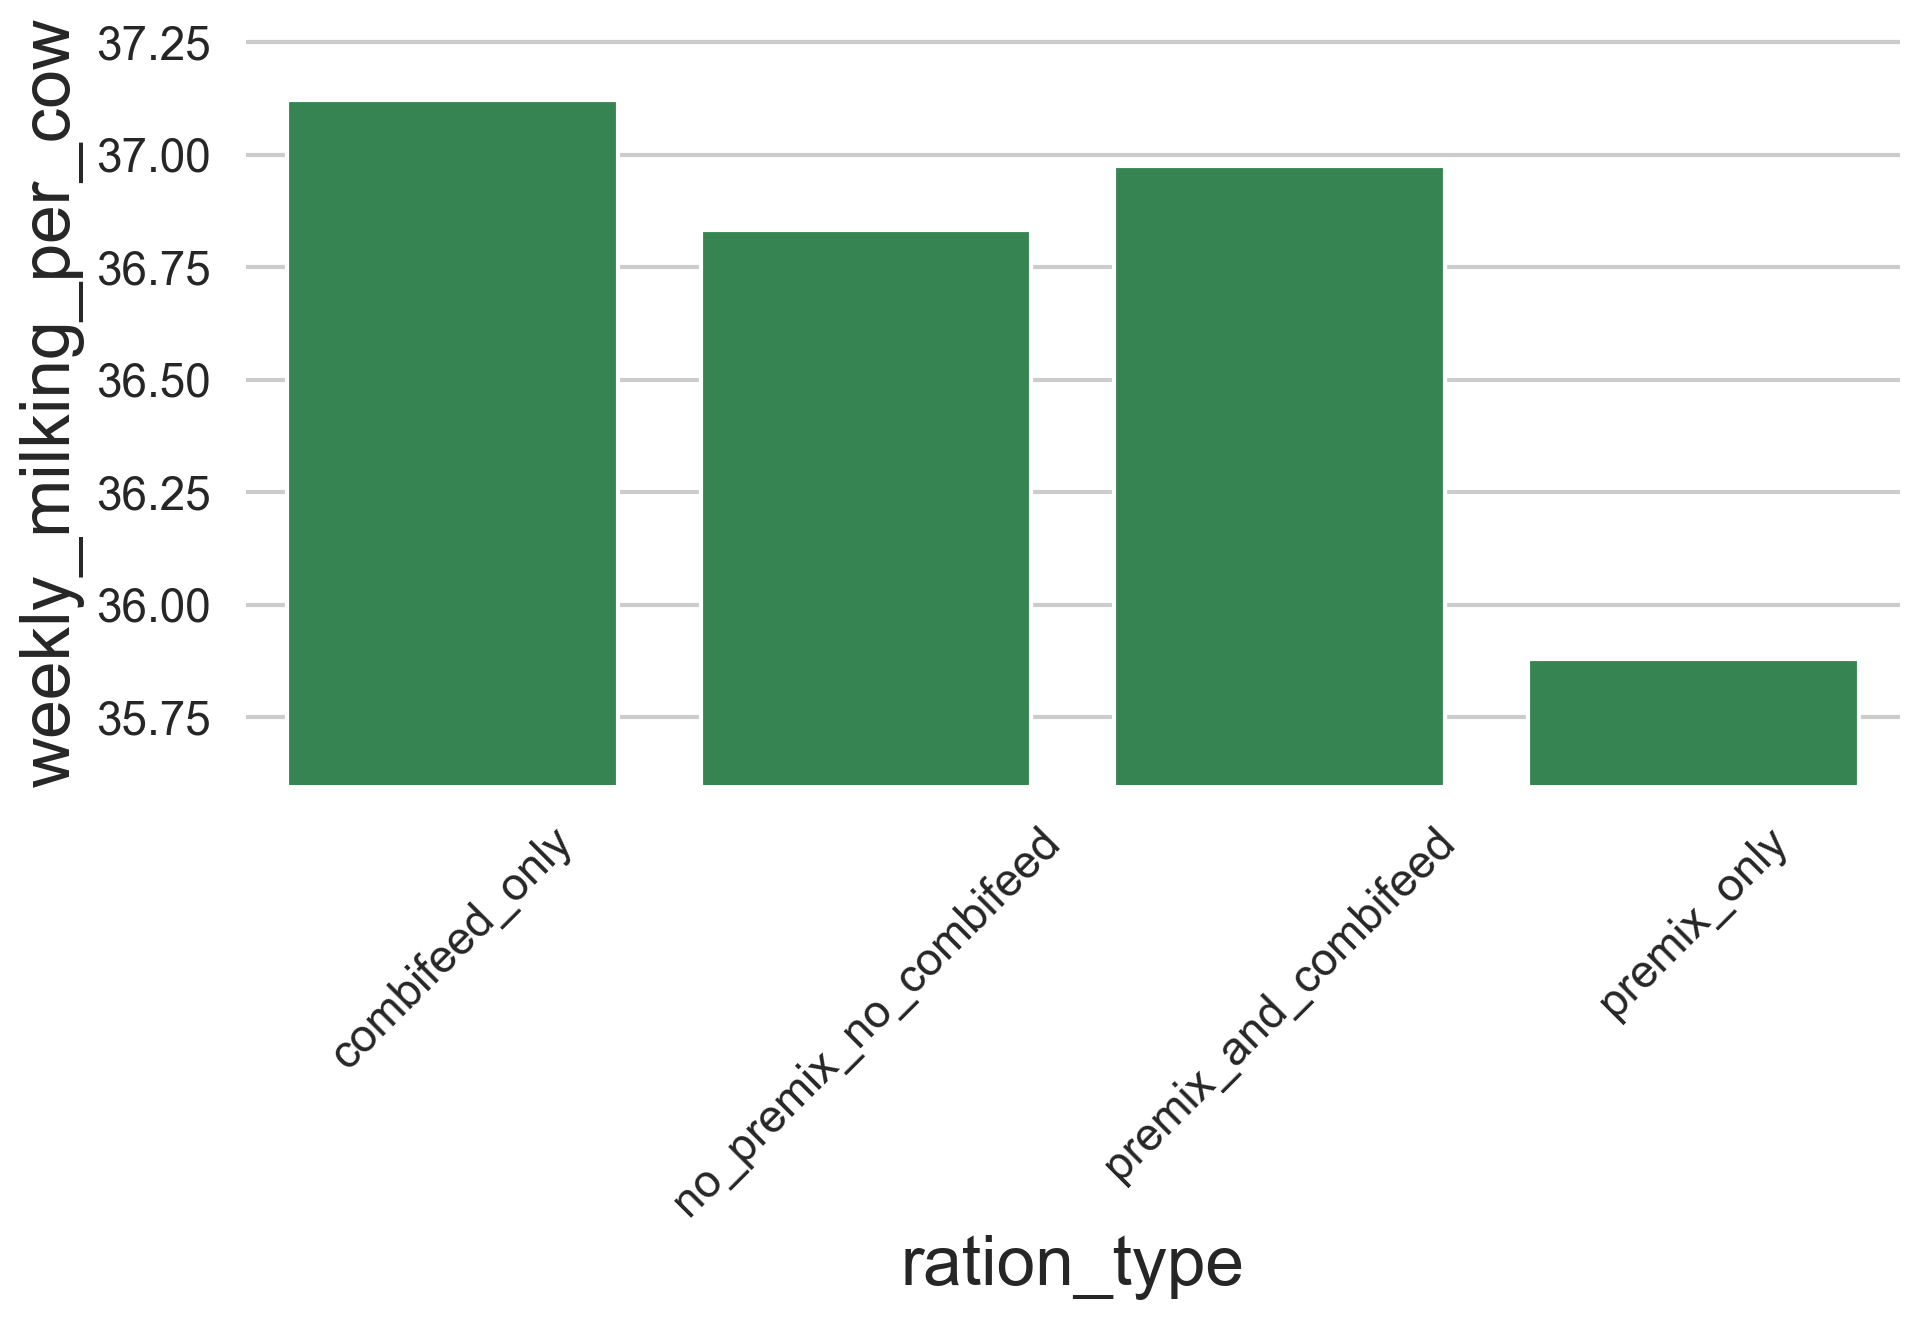

In [80]:
sns.barplot(data=dd.groupby('ration_type')['weekly_milking_per_cow'].mean().reset_index(), x='ration_type', y='weekly_milking_per_cow')
plt.ylim(35.6, 37.3)
plt.xticks(rotation=45);

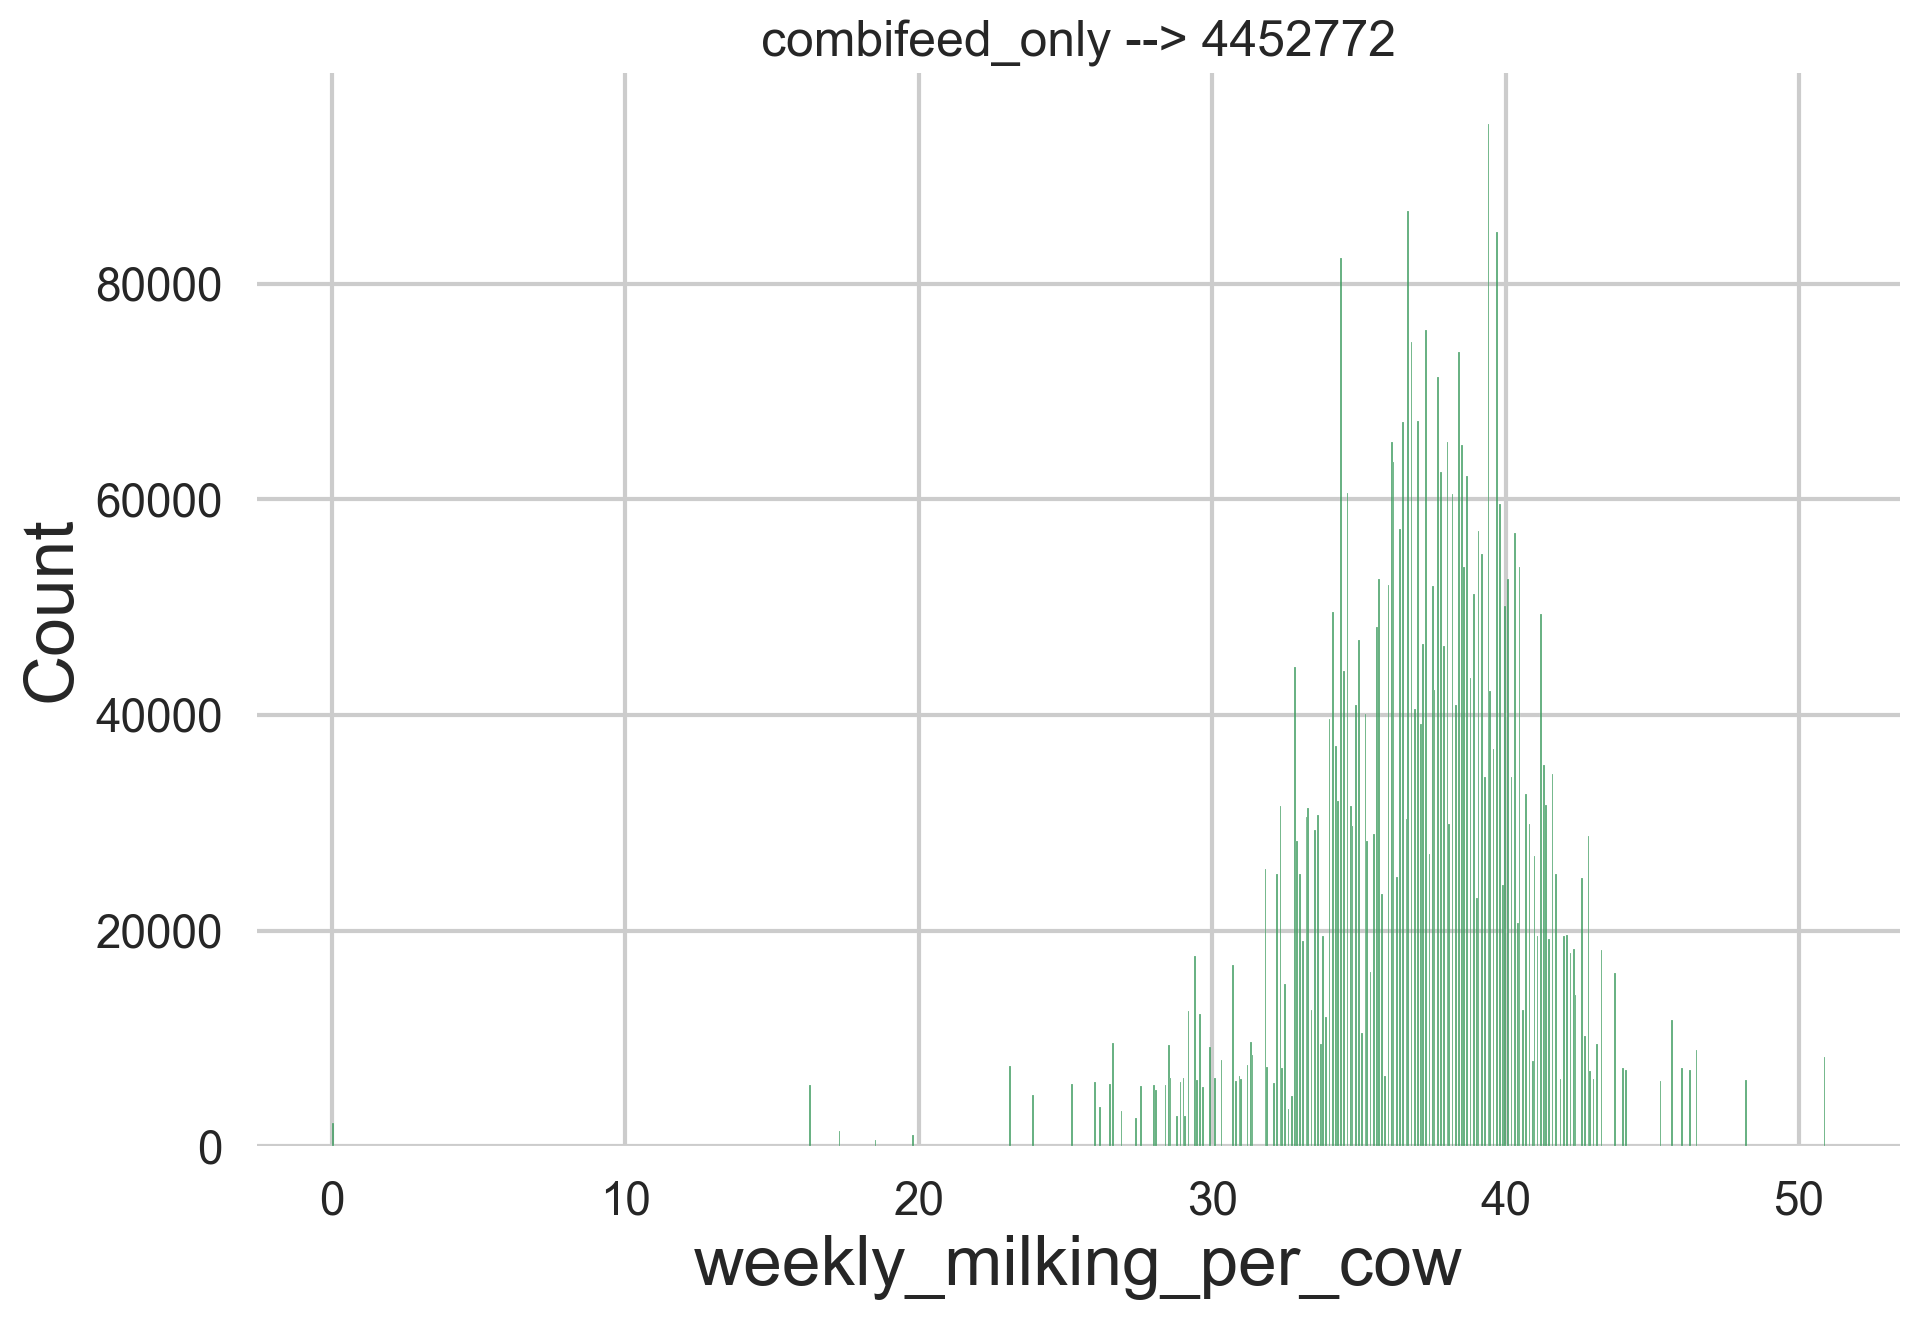

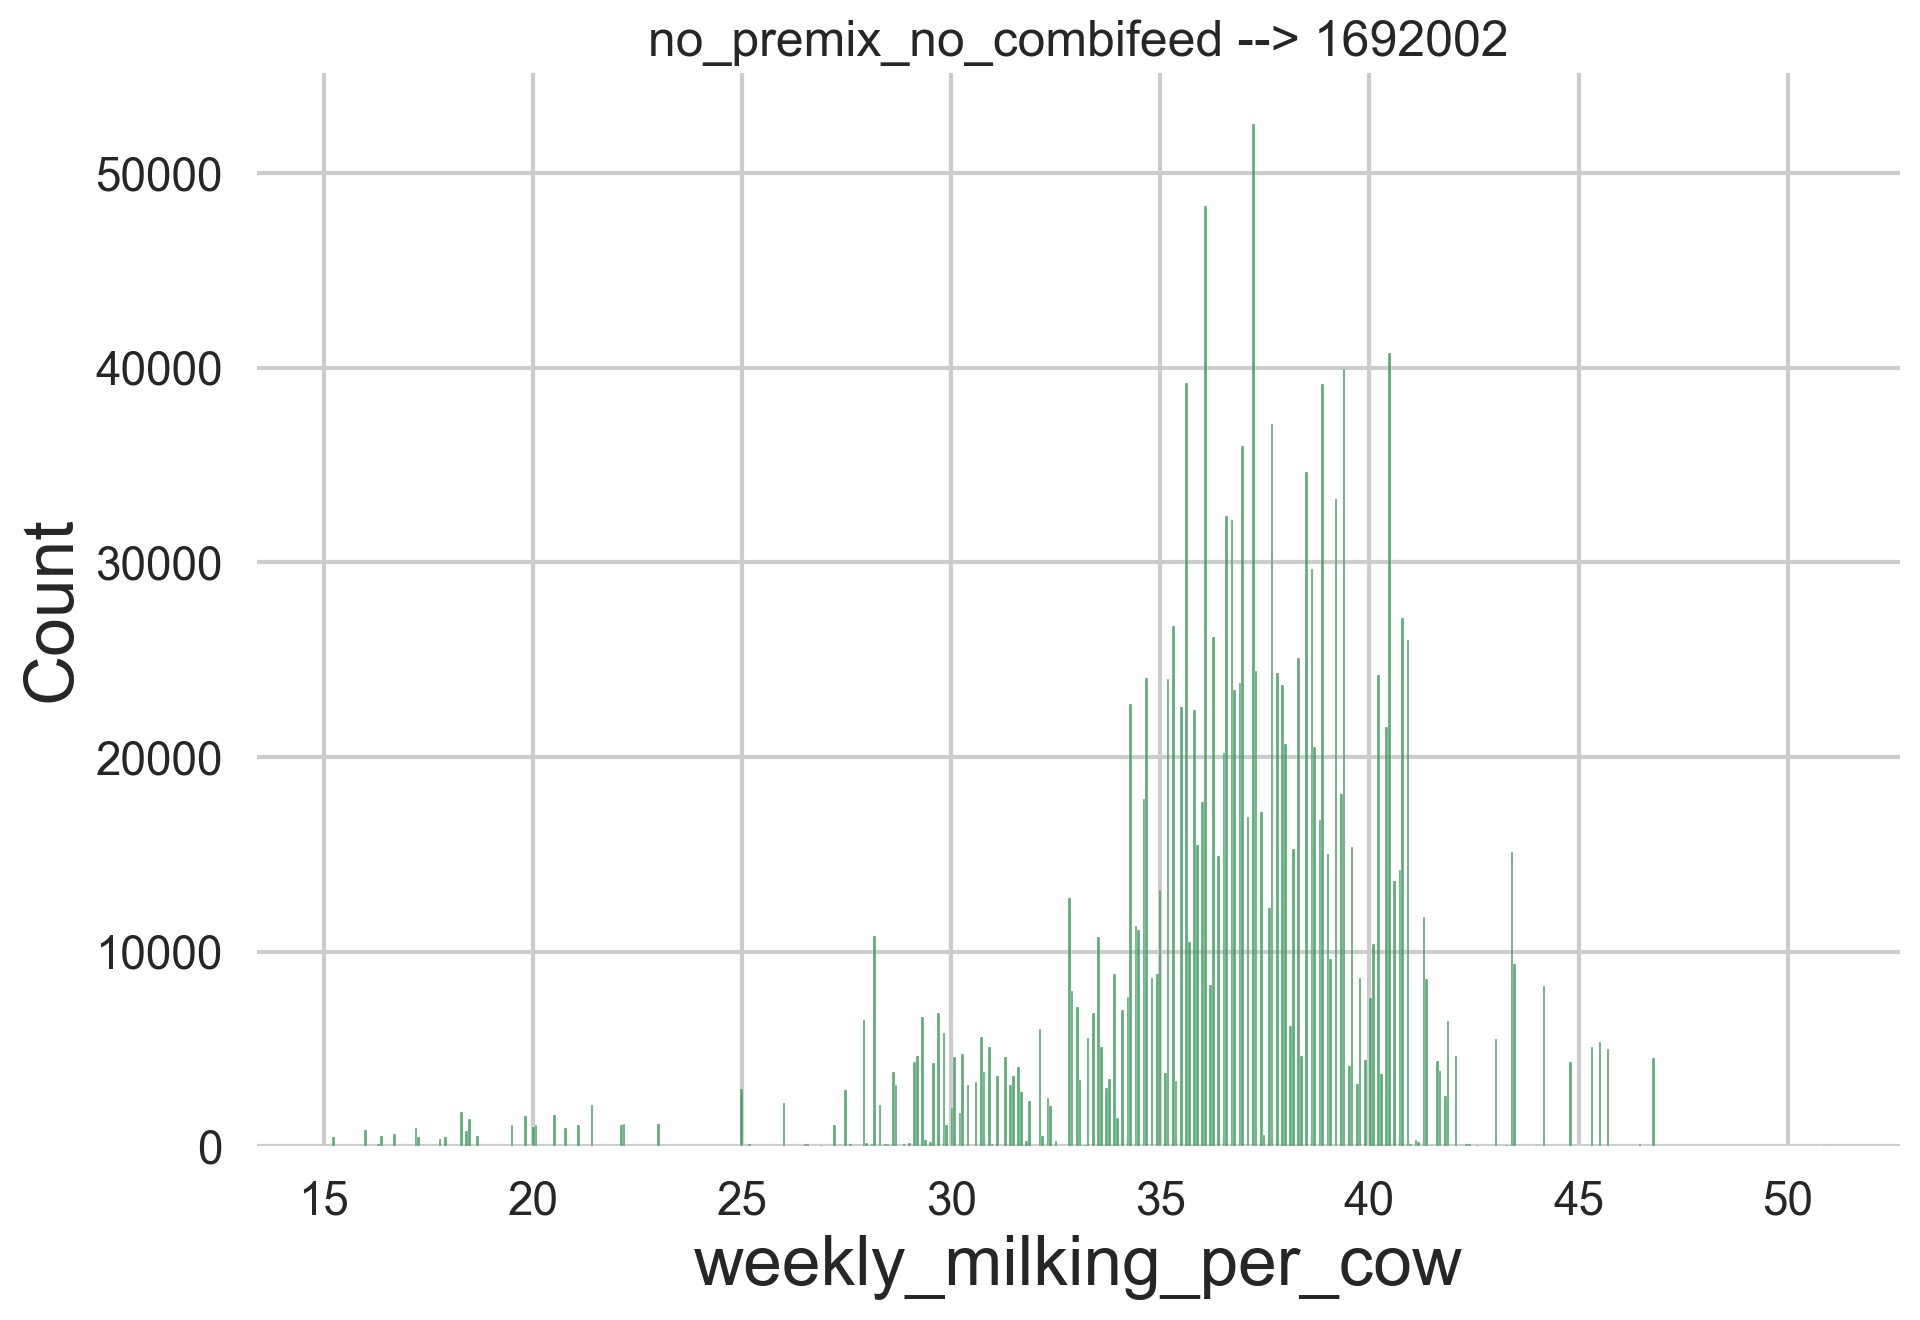

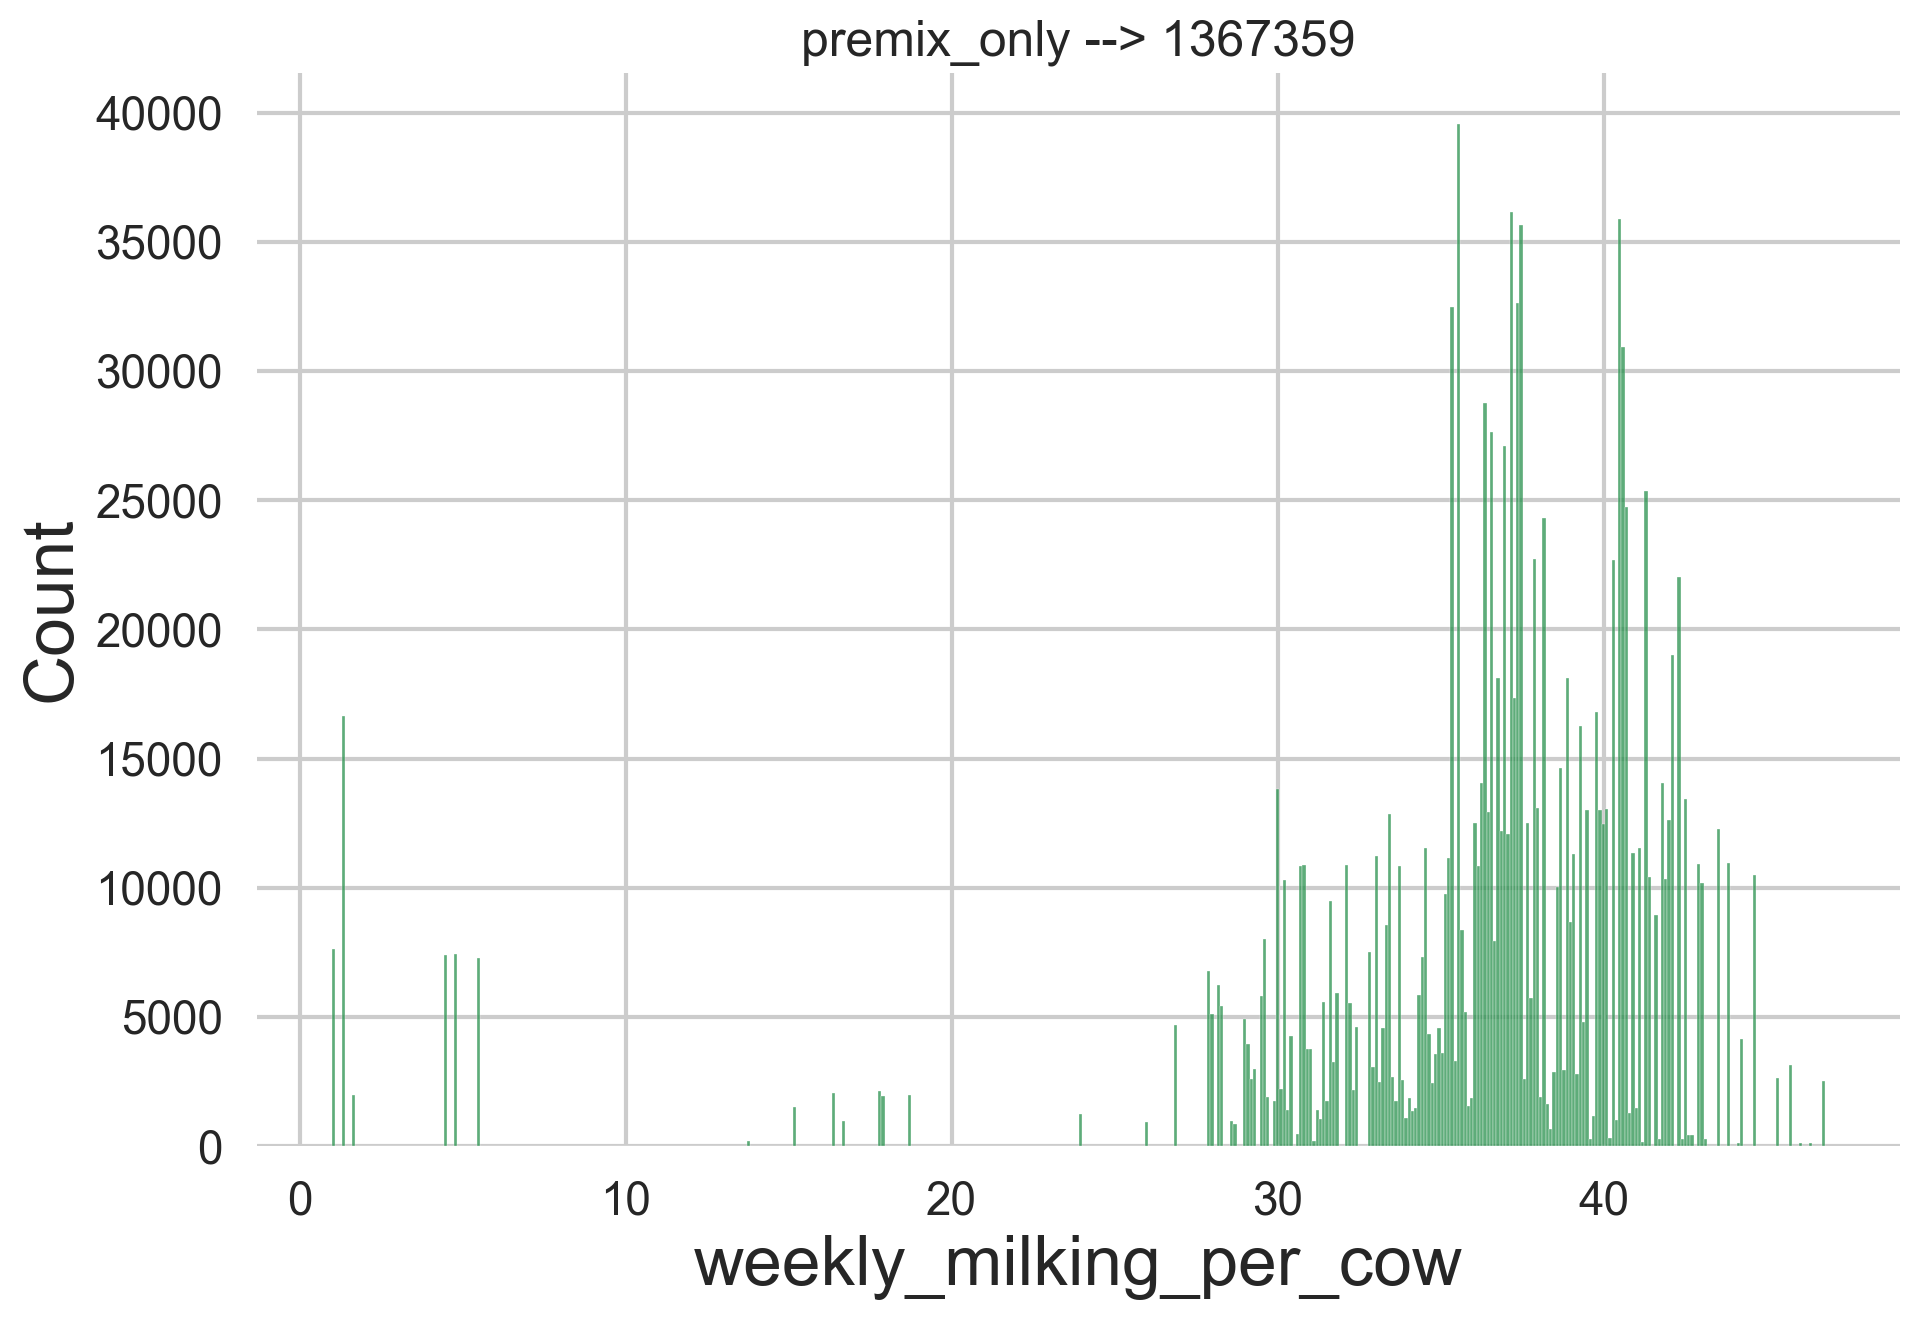

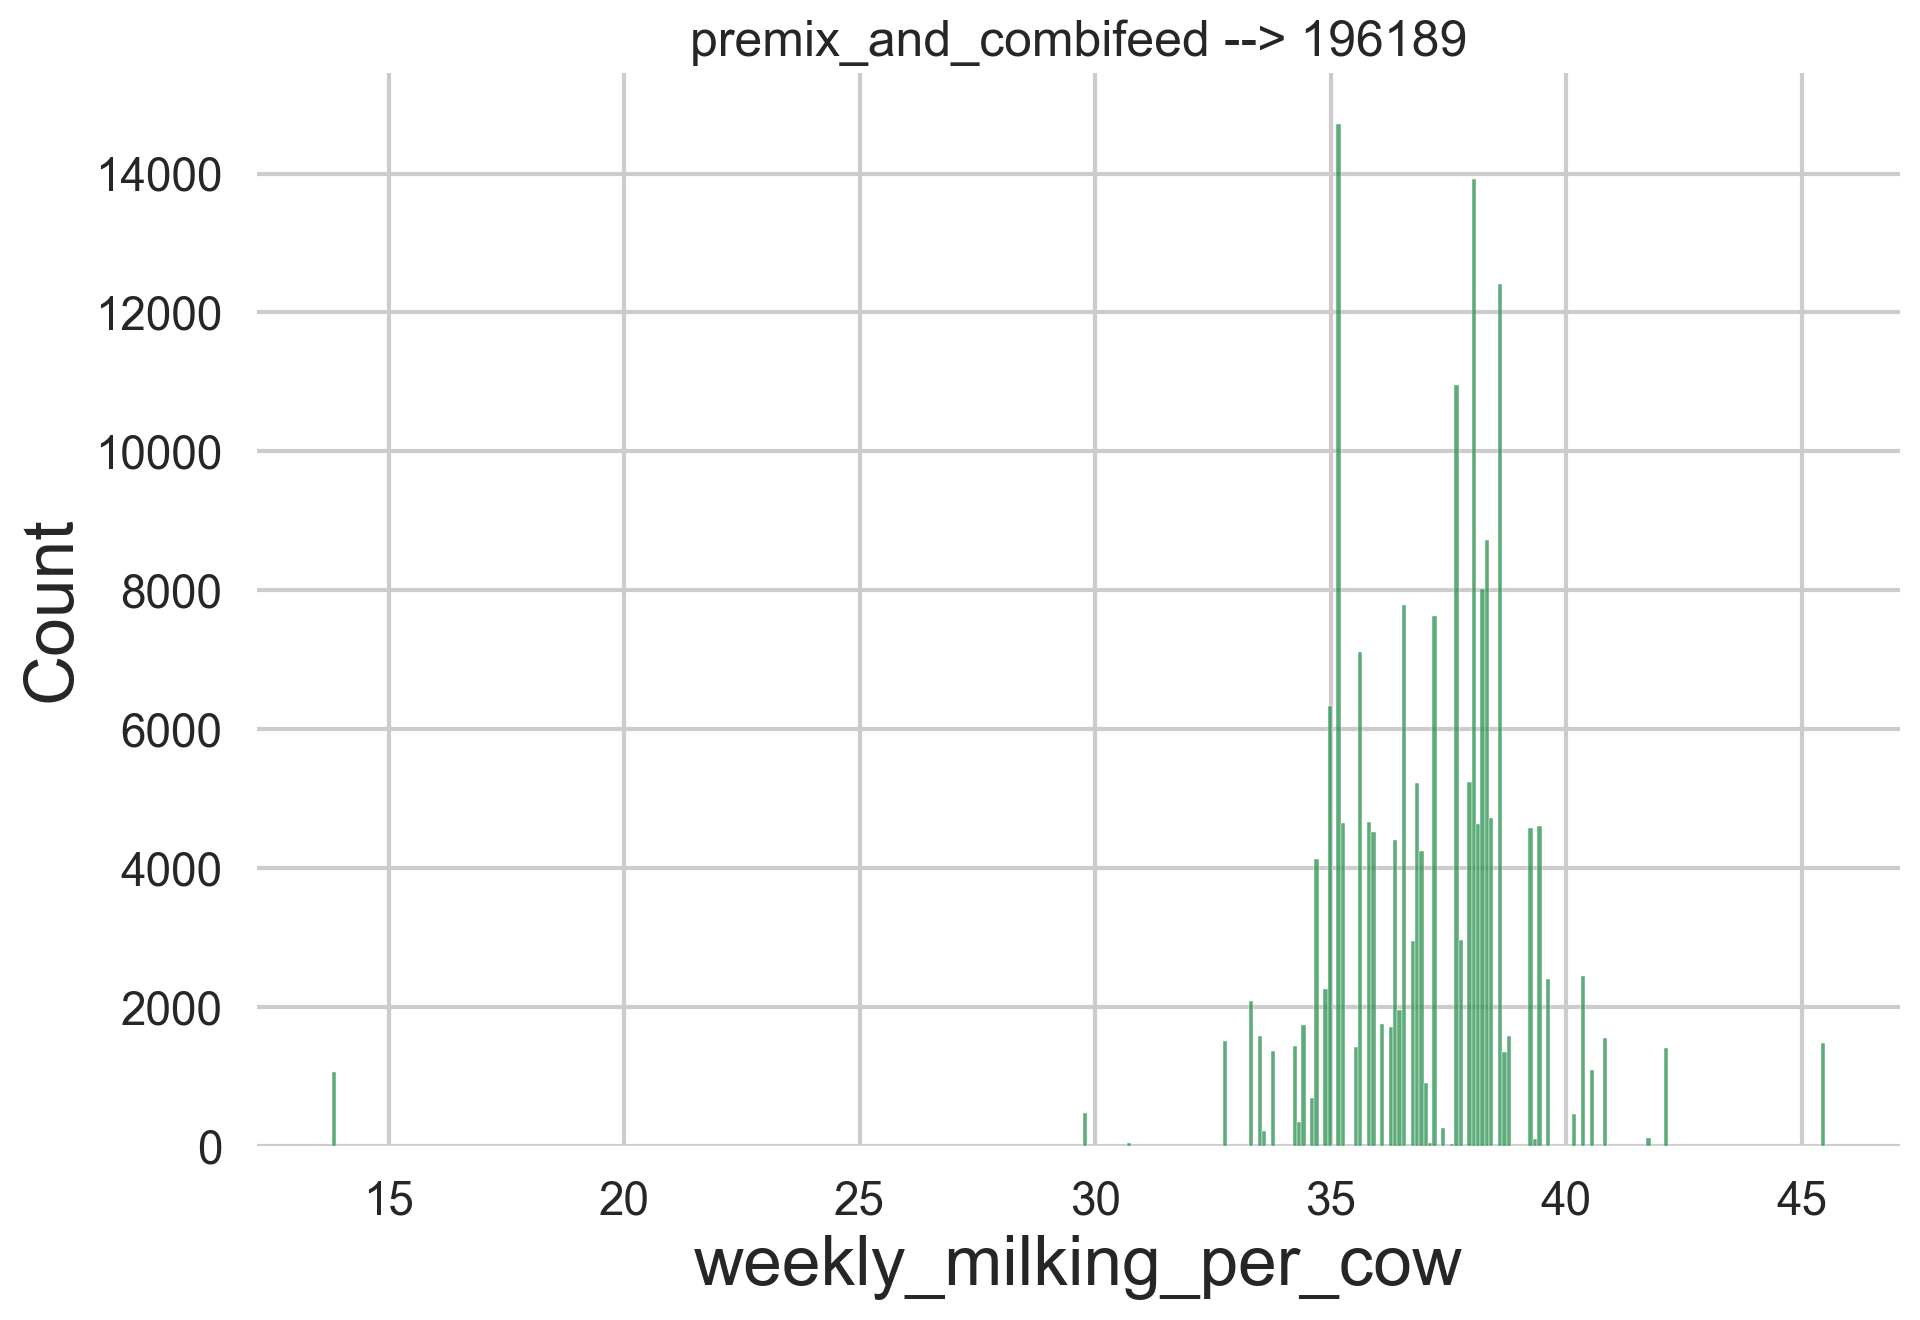

In [81]:
for rt in dd['ration_type'].unique():
    plt.subplots()
    dd2 = dd[dd['ration_type'] == rt]
    sns.histplot(data=dd2, x='weekly_milking_per_cow')
    plt.title(f'{rt} --> {dd2.shape[0]}', fontsize=18)

In [82]:
df = dd.copy()
df['weekly_milking_per_cow'] = pd.to_numeric(df['weekly_milking_per_cow'], errors='coerce')
df = df.dropna(subset=['weekly_milking_per_cow', 'ration_type'])

In [83]:
from scipy.stats import f_oneway

groups = [
    g['weekly_milking_per_cow'].values
    for _, g in df.groupby('ration_type')
]

f_stat, p_val = f_oneway(*groups)

print("ANOVA F =", f_stat)
print("ANOVA p =", p_val)

ANOVA F = 25166.40049511183
ANOVA p = 0.0


In [84]:
from scipy.stats import kruskal

kw_stat, kw_p = kruskal(*groups)

print("Kruskal–Wallis H =", kw_stat)
print("Kruskal p =", kw_p)

Kruskal–Wallis H = 5397.776138138839
Kruskal p = 0.0


In [85]:
features = fad["ingredient_group"].unique().tolist()
features

['Объёмные корма',
 'Комбикорма и стартеры',
 'Энергетические и крахмалистые корма',
 'Белковые корма',
 'Жиры и глюкозогенные добавки',
 'Жидкости',
 'Премиксы, БАДы, дрожжи',
 'Минералы/буферные',
 'Жом и дробина',
 'Остатки']

In [ ]:
def make_windows(df, win=60, total=90):
    df = df.sort_values("date")
    windows = []
    for i in range(total - win + 1):
        win_df = df.iloc[i:i+win]
        windows.append(win_df)
    return windows

def window_to_vector(win_df):
    means = win_df[["1","2","3","4","5"]].mean().values
    stds = win_df[["1","2","3","4","5"]].std().values
    return np.concatenate([means, stds])


from hyppo.ksample import KSample

def make_rolling_windows(df, win_size=60, horizon_days=None):
    """
    df: DataFrame с колонками 'date' и фичами рациона.
    win_size: размер окна (в днях)
    horizon_days: опционально обрезать до первых horizon_days строк.
                  Если None — берём весь df как горизонт.

    Возвращает список окон (каждое окно — DataFrame).
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    if horizon_days is not None:
        df = df.iloc[:horizon_days].reset_index(drop=True)

    n = len(df)
    if n < win_size:
        raise ValueError(f"Слишком мало данных: {n} строк при окне {win_size}")

    windows = []
    n_windows = n - win_size + 1  # классическое скользящее окно
    for start in range(n_windows):
        win_df = df.iloc[start:start + win_size]
        windows.append(win_df)

    return windows


# ---------- ФУНКЦИЯ: проверка стабильности питания в 90-дневном блоке ----------

def analyze_nutrition_windows(
    df_block,
    metrics_cols,
    win_size=60,
    alpha=0.05,
):
    """
    df_block: DataFrame для ОДНОГО 90-дневного блока (одна ферма, 90 дней подряд).
    metrics_cols: список колонок с признаками рациона.
    win_size: размер внутренних окон (например, 60 дней).
    alpha: уровень значимости.

    Логика:
      1) Нарезаем блок на скользящие окна размера win_size (обычно 60) дней.
      2) Для каждого окна берём матрицу (win_size × n_features).
      3) Применяем k-sample тест (KSample c Dcorr) ко всем окнам сразу.
         H0: распределения рациона во всех окнах одинаковы (рацион стабилен).
      4) Если p > alpha → рацион считаем стабильным.

    Возвращает dict:
        - 'is_stable': bool
        - 'p_value': float
        - 'statistic': float
        - 'mean_nutrition': pd.Series (средние значения признаков по блоку)
    """
    # 1. Нарезаем блок на скользящие окна
    windows = make_rolling_windows(df_block, win_size=win_size, horizon_days=None)

    # 2. Превращаем окна в массивы (каждое: shape = (win_size, n_features))
    samples = [w[list(metrics_cols)].to_numpy() for w in windows]

    # 3. K-sample тест равенства распределений (рацион одинаков во всех окнах?)
    stat, p_value = KSample(indep_test="Dcorr").test(*samples)
    is_stable = p_value > alpha

    # 4. Если рацион стабильный — считаем среднее питание по блоку
    mean_nutrition = df_block[list(metrics_cols)].mean() if is_stable else None

    return {
        "is_stable": is_stable,
        "p_value": p_value,
        "statistic": stat,
        "mean_nutrition": mean_nutrition,




def get_time_row_metrit(df_monthly):
    df = df_monthly.copy()
    df["year_month"] = pd.to_datetime(df["year_month"], format="%Y-%m")
    df["days_in_month"] = df["year_month"].dt.days_in_month
    df["metrit_per_day"] = df["cow_metrit"] / df["days_in_month"] / df["calves"]

    rows = []
    for _, row in df.iterrows():
        start = row["year_month"]
        end = start + pd.offsets.MonthEnd(0)
        dates = pd.date_range(start=start, end=end, freq="D")
        for d in dates:
            rows.append({
                "date": d,
                "metrit_cow_daily": row["metrit_per_day"],
            })

    daily_df = pd.DataFrame(rows)
    return daily_df


In [87]:
features = fad["ingredient_group"].unique().tolist()
features

['Объёмные корма',
 'Комбикорма и стартеры',
 'Энергетические и крахмалистые корма',
 'Белковые корма',
 'Жиры и глюкозогенные добавки',
 'Жидкости',
 'Премиксы, БАДы, дрожжи',
 'Минералы/буферные',
 'Жом и дробина',
 'Остатки']

In [88]:
dff = get_time_row_metrit(herd_metrics)

In [89]:
dfc = pd.read_csv("datasets/FeedingPreLast.csv", index_col=0).rename(columns={"Date": "date"})
dfc

,date,farm_name,Белковые корма,Жидкости,Жиры и глюкозогенные добавки,Жом и дробина,Комбикорма и стартеры,Минералы/буферные,Объёмные корма,Остатки,"Премиксы, БАДы, дрожжи",Энергетические и крахмалистые корма
0,2022-01-05,ЖК Добрино,2.029072,1.823163,0.0,0.000000,0.000000,0.251922,27.385651,0.0,0.295665,1.063867
1,2022-01-05,ЖК Коршево,0.709130,3.684383,0.0,0.000000,2.019473,0.218880,30.028700,0.0,0.063687,0.000000
2,2022-01-06,ЖК Добрино,2.269377,1.811687,0.0,0.000000,0.000000,0.249424,27.324712,0.0,0.294141,0.885715
3,2022-01-06,ЖК Коршево,0.825975,3.716895,0.0,0.000000,1.982343,0.218610,30.772119,0.0,0.063617,0.000000
4,2022-01-07,ЖК Добрино,1.720963,1.624439,0.0,0.000000,0.000000,0.217664,27.792455,0.0,0.274031,0.706280
...,...,...,...,...,...,...,...,...,...,...,...,...
44778,2025-10-26,ЖК Семено-Макарово,3.000000,0.000000,0.0,1.250000,0.000000,0.000000,40.085714,0.0,0.187000,0.000000
44779,2025-10-26,ЖК Старая Чигла,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,41.940299,0.0,0.347881,0.000000
44780,2025-10-26,ЖК Старое Резяпкино,1.412407,0.000000,0.0,2.344736,0.778193,0.000000,31.115036,0.0,0.191114,0.000000
44781,2025-10-26,ЖК Уланово,0.000000,5.157159,0.0,0.000000,0.000000,0.000000,20.304945,0.0,0.000000,0.000000


In [90]:
dfc["farm_name"].unique()

array(['ЖК Добрино', 'ЖК Коршево', 'ЖК Бодеевка', 'ЖК Высокое',
       'МТФ Высокое', 'ЖК Петропавловка', 'ЖК Верхний Икорец',
       'ЖК Бобров', 'ЖК Бобров 2', 'ЖК Старая Чигла', 'ЖК Песковатка',
       'ЖК Колыбелка', 'ЖК Петровское', 'ЖК Залужное', 'ЖК Волчанское',
       'ЖК Щучье', 'ЖК Озерки', 'МТФ Щучье', 'ЖК Болдасовка',
       'ЖК Уланово', 'ЖК Богданино', 'ЖК Бушовка', 'ЖК Гусево',
       'ЖК Курская Васильевка', 'ЖК Семено-Макарово', 'ЖК Наратлы',
       'ЖК Детчинское', 'ЖК Огнева Заимка', 'ЖК Нестерово', 'ЖК Авангард',
       'ЖК Шацк', 'ЖК Зимитицы', 'ЖК Подболотье', 'ЖК Елбань',
       'ЖК Плеханово', 'ЖК Пеньково', 'ЖК Бортниково', 'МТФ Гилево',
       'МТФ Каширинское', 'ЖК Старое Резяпкино', 'ЖК Курочкино',
       'ЖК Сугоново', 'ЖК Аристово', 'ЭФ Родня', 'ЖК Пеневичи',
       'РМ Кольцово', 'ЖК Борково', 'МТФ Романово'], dtype=object)

In [91]:
analyze_nutrition_windows(dfc, features)

{'is_stable': np.True_,
 'p_value': np.float64(1.0),
 'statistic': -0.004248010651409176,
 'mean_nutrition': Объёмные корма                         26.726042
 Комбикорма и стартеры                   0.666498
 Энергетические и крахмалистые корма     0.315152
 Белковые корма                          1.269521
 Жиры и глюкозогенные добавки            0.000000
 Жидкости                                2.132575
 Премиксы, БАДы, дрожжи                  0.170537
 Минералы/буферные                       0.258279
 Жом и дробина                           0.000000
 Остатки                                 0.000000
 dtype: float64}

In [92]:

def build_metrit_ration_dataset(
    df,
    ration_feature_cols,
    win_size=60,
    block_size=90,
    alpha=0.05,
    take_first_days=30,
):
    """
    df: большой датафрейм со столбцами:
        - 'date'
        - 'farm_name'
        - 'cow_metrit_per_day'
        - фичи корма (ration_feature_cols)

    ration_feature_cols: список названий колонок, описывающих рацион
                         (калории, белок, сахар, вода, и т.д.)

    win_size: размер внутренних окон для анализа стабильности (обычно 60 дней).
    block_size: размер внешнего блока, по которому проверяем стабильность (обычно 90 дней).
    alpha: уровень значимости для теста стабильности рациона.
    take_first_days: сколько первых дней из 90 использовать для связи
                     питание ↔️ метрит (из-за лагов/отёла; ты указал 30).
Логика:
      - Для каждой фермы делим данные на последовательные НЕпересекающиеся 90-дневные блоки.
      - Для каждого блока:
          * вызываем analyze_nutrition_windows;
          * если рацион стабилен (is_stable=True):
              - считаем среднее питание по блоку;
              - берём первые take_first_days строк блока
              - для каждого дня записываем:
                    date, farm_name, cow_metrit_per_day,
                    средние фичи рациона по блоку
              - эти строки попадают в good_rows_df
          * в любом случае логируем блок в windows_log_df
            (farm_name, start_date, end_date, p_value, statistic, is_stable)

    Возвращает:
      - good_rows_df: строки, где питание стабильно и можно честно связывать его с метритами
      - windows_log_df: лог всех 90-дневных окон (для анализа доли "нормальных" блоков)
    """

    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    good_rows = []
    windows_log = []

    # Итерируем по фермам
    for farm, farm_df in df.groupby("farm_name"):
        farm_df = farm_df.sort_values("date").reset_index(drop=True)

        n = len(farm_df)
        # идём последовательными блоками по 90 дней, без перекрытия
        start_idx = 0
        block_id = 0
        while start_idx + block_size <= n:
            block_df = farm_df.iloc[start_idx:start_idx + block_size].copy()
            block_id += 1

            block_start_date = block_df["date"].iloc[0]
            block_end_date = block_df["date"].iloc[-1]

            # Анализируем стабильность рациона в этом блоке
            analysis = analyze_nutrition_windows(
                df_block=block_df,
                metrics_cols=ration_feature_cols,
                win_size=win_size,
                alpha=alpha,
            )

            is_stable = analysis["is_stable"]
            p_value = analysis["p_value"]
            stat = analysis["statistic"]
            mean_nutrition = analysis["mean_nutrition"]

            # Логируем блок
            windows_log.append({
                "farm_name": farm,
                "block_id": block_id,
                "start_date": block_start_date,
                "end_date": block_end_date,
                "is_stable": is_stable,
                "p_value": p_value,
                "statistic": stat,
                "n_days": block_size,
            })

            # Если рацион стабильный — создаём записи для первых take_first_days дней
            if is_stable:
                sub_days = block_df.iloc[:take_first_days].copy()
                for _, row in sub_days.iterrows():
                    row_dict = {
                        "farm_name": farm,
                        "date": row["date"],
                        "cow_metrit_per_day": row["cow_metrit_per_day"],
                        "block_id": block_id,
                        "block_start_date": block_start_date,
                        "block_end_date": block_end_date,
                    }
                    # добавляем среднее питание по блоку (фичи рациона)
                    for col in ration_feature_cols:
                        row_dict[f"mean_{col}"] = mean_nutrition[col]

                    good_rows.append(row_dict)

            # переходим к следующему не пересекающемуся 90-дневному блоку
            start_idx += block_size

    good_rows_df = pd.DataFrame(good_rows)
    windows_log_df = pd.DataFrame(windows_log)

    return good_rows_df, windows_log_df


,date,farm_name,Белковые корма,Жидкости,Жиры и глюкозогенные добавки,Жом и дробина,Комбикорма и стартеры,Минералы/буферные,Объёмные корма,Остатки,"Премиксы, БАДы, дрожжи",Энергетические и крахмалистые корма
0,2022-01-05,ЖК Добрино,2.029072,1.823163,0.0,0.000000,0.000000,0.251922,27.385651,0.0,0.295665,1.063867
1,2022-01-05,ЖК Коршево,0.709130,3.684383,0.0,0.000000,2.019473,0.218880,30.028700,0.0,0.063687,0.000000
2,2022-01-06,ЖК Добрино,2.269377,1.811687,0.0,0.000000,0.000000,0.249424,27.324712,0.0,0.294141,0.885715
3,2022-01-06,ЖК Коршево,0.825975,3.716895,0.0,0.000000,1.982343,0.218610,30.772119,0.0,0.063617,0.000000
4,2022-01-07,ЖК Добрино,1.720963,1.624439,0.0,0.000000,0.000000,0.217664,27.792455,0.0,0.274031,0.706280
...,...,...,...,...,...,...,...,...,...,...,...,...
44778,2025-10-26,ЖК Семено-Макарово,3.000000,0.000000,0.0,1.250000,0.000000,0.000000,40.085714,0.0,0.187000,0.000000
44779,2025-10-26,ЖК Старая Чигла,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,41.940299,0.0,0.347881,0.000000
44780,2025-10-26,ЖК Старое Резяпкино,1.412407,0.000000,0.0,2.344736,0.778193,0.000000,31.115036,0.0,0.191114,0.000000
44781,2025-10-26,ЖК Уланово,0.000000,5.157159,0.0,0.000000,0.000000,0.000000,20.304945,0.0,0.000000,0.000000
